<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 133 · Forecasting Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Energy Demand Forecasting</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">The multiple-seasonality forecasting problem on four years of daily electricity demand: separate the weekly and yearly cycles with MSTL, then beat a one-season Holt-Winters with a harmonic regression that captures both seasons using day-of-week dummies and yearly Fourier terms, backtested and graded with the full accuracy panel.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Case Study: Energy Demand Forecasting
Electricity demand is the classic **multiple-seasonality** forecasting problem: it rises and falls with the **day of the week** (weekday vs weekend) AND with the **time of year** (winter heating, summer cooling), both at once. That breaks the one-season tools like Holt-Winters and SARIMA. This case study takes four years of daily demand, decomposes the two cycles with **MSTL**, and forecasts with a **harmonic regression** that captures both, then grades it against a baseline and a one-season model.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings('ignore')
def mape(a,f): return float(np.mean(np.abs((a.values-np.asarray(f))/a.values))*100)
def mae(a,f): return float(np.mean(np.abs(a.values-np.asarray(f))))
def rmse(a,f): return float(np.sqrt(np.mean((a.values-np.asarray(f))**2)))

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What are we forecasting, and why?</div>
<div style="color:#4a5578;margin-top:6px">Daily demand, to keep the grid balanced.</div>
</div>

A grid operator must forecast **daily electricity demand** to schedule generation, buy power, and avoid both shortfalls and waste. Success: beat a seasonal-naive baseline, keep the error (MAPE) low, and, critically, capture <strong>both</strong> seasonal rhythms, missing either the weekend dip or the summer peak means mis-scheduling capacity.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; COLLECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Four years of daily demand</div>
<div style="color:#4a5578;margin-top:6px">One value per day.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/ch133_energy_demand.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch133_energy_demand.xlsx', sheet_name='Data')
raw['date']=pd.to_datetime(raw['date']); s = raw.set_index('date')['demand_mw'].asfreq('D')
print('days:', len(s), '| from', s.index.min().date(), 'to', s.index.max().date())

days: 1461 | from 2020-01-01 to 2023-12-31


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two rhythms at once</div>
<div style="color:#4a5578;margin-top:6px">Zoom out for the year, zoom in for the week.</div>
</div>

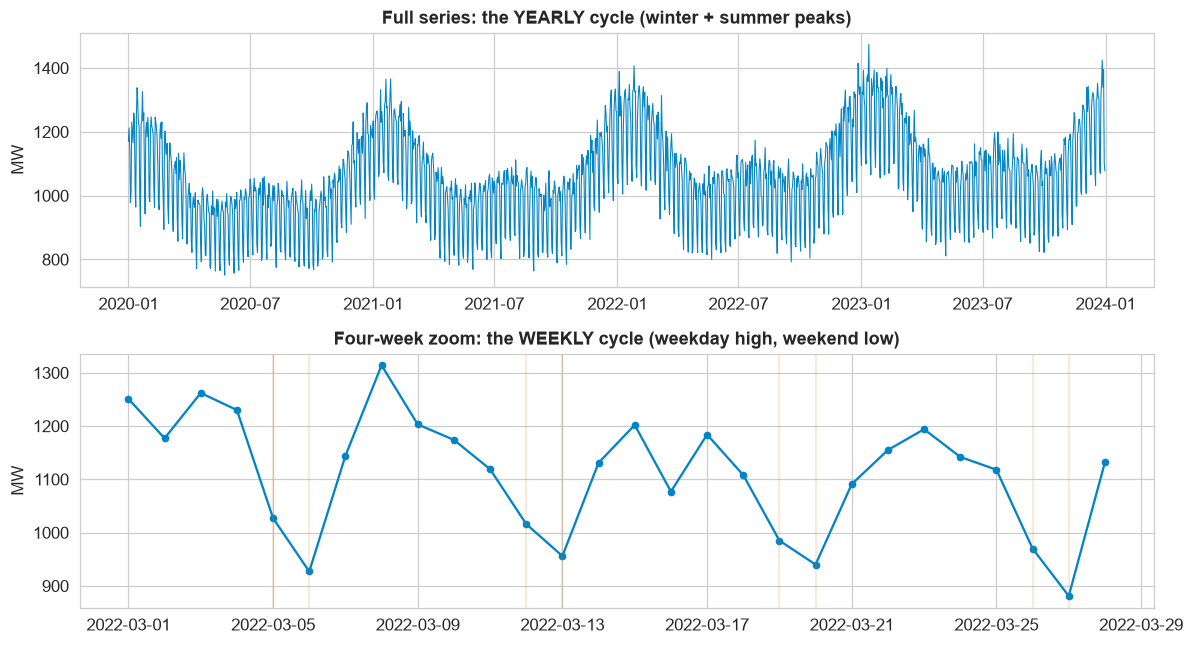

weekday avg 1113 MW vs weekend avg 911 MW


In [4]:
fig,ax=plt.subplots(2,1,figsize=(11,6))
ax[0].plot(s.index, s.values, color=EM, lw=0.7); ax[0].set(title='Full series: the YEARLY cycle (winter + summer peaks)', ylabel='MW')
wk=s['2022-03-01':'2022-03-28']; ax[1].plot(wk.index, wk.values, 'o-', color=EM, ms=4); ax[1].set(title='Four-week zoom: the WEEKLY cycle (weekday high, weekend low)', ylabel='MW')
for d in wk.index[wk.index.dayofweek>=5]: ax[1].axvline(d, color=AMBER, alpha=0.15)
plt.tight_layout(); plt.show()
print('weekday avg %d MW vs weekend avg %d MW' % (s[s.index.dayofweek<5].mean(), s[s.index.dayofweek>=5].mean()))

Two patterns are layered on top of each other. Zoomed out, a slow <strong>yearly</strong> cycle with winter and summer peaks; zoomed into a month, a sharp <strong>weekly</strong> cycle, weekdays run about <strong>1,113 MW</strong> and weekends drop to about <strong>911 MW</strong> (shaded). A good model must reproduce both.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 4 &#183; DECOMPOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Separate the two seasons with MSTL</div>
<div style="color:#4a5578;margin-top:6px">One tool, multiple seasonal periods.</div>
</div>

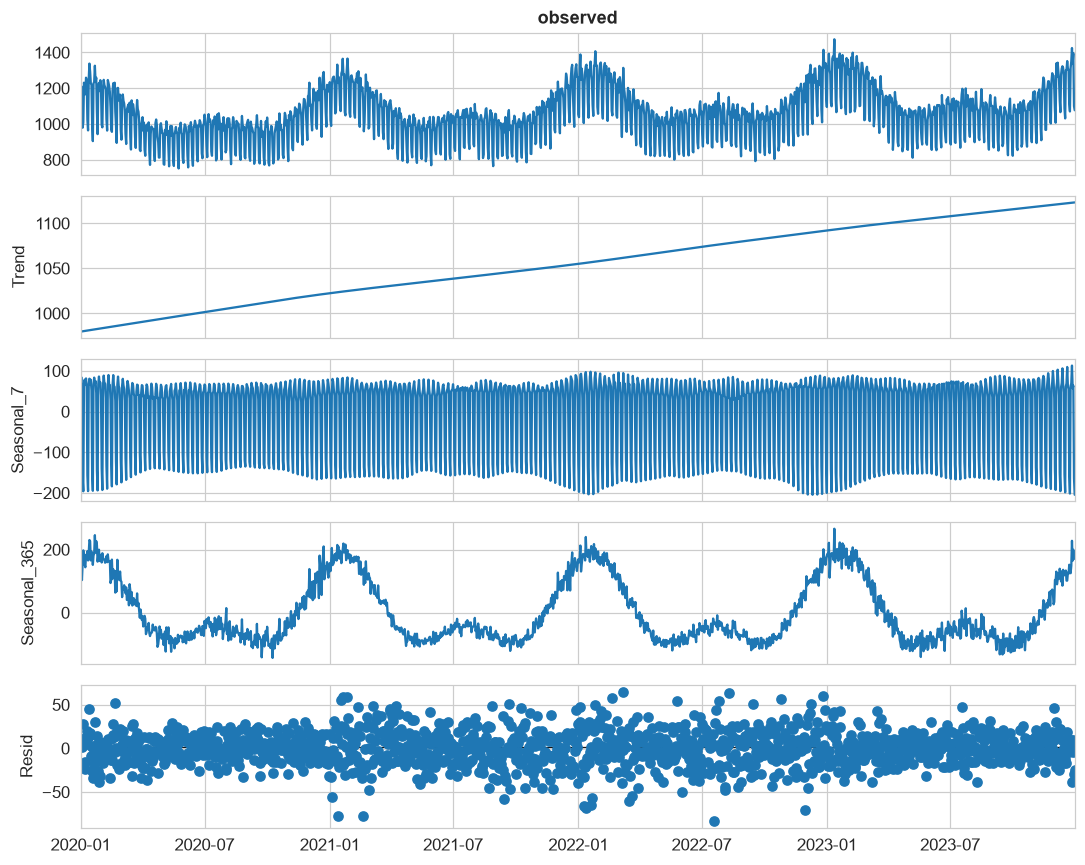

weekly component amplitude ~ 94 MW | yearly component amplitude ~ 98 MW


In [5]:
mstl = MSTL(s, periods=(7, 365)).fit()
fig = mstl.plot(); fig.set_size_inches(10,8); plt.tight_layout(); plt.show()
print('weekly component amplitude ~ %.0f MW | yearly component amplitude ~ %.0f MW' % (mstl.seasonal['seasonal_7'].std(), mstl.seasonal['seasonal_365'].std()))

Ordinary decomposition handles one season; <strong>MSTL</strong> (Multiple STL) peels off <strong>several</strong>. It splits the series into a trend, a <strong>weekly</strong> component, a <strong>yearly</strong> component, and a small residual. Both seasonal swings are sizable (about 94 and 98 MW), so a model that captures only one will leave real, systematic error on the table.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 5 &#183; STATIONARITY &amp; THE CHALLENGE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">No differencing needed, but two seasons</div>
<div style="color:#4a5578;margin-top:6px">The real difficulty is the multiple seasonality.</div>
</div>

In [6]:
print('ADF p = %.3f -> %s' % (adfuller(s)[1], 'trend-stationary (no unit root)' if adfuller(s)[1]<0.05 else 'non-stationary'))
print('the trend is mild, so we model trend + seasonality DIRECTLY rather than differencing.')
print('the genuine challenge: TWO seasonal periods (7 and 365) that one-season models cannot both capture.')

ADF p = 0.008 -> trend-stationary (no unit root)
the trend is mild, so we model trend + seasonality DIRECTLY rather than differencing.
the genuine challenge: TWO seasonal periods (7 and 365) that one-season models cannot both capture.


Unlike the retail series, this one is <strong>trend-stationary</strong> (ADF p &lt; 0.05): the trend is gentle, so we model it directly instead of differencing. The real obstacle is the <strong>double seasonality</strong>. <strong>Holt-Winters and SARIMA each support only one seasonal period</strong>, so they can fit the weekly cycle or the yearly one, but not both. That is the modeling decision this chapter turns on.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 6 &#183; SPLIT &amp; BASELINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Hold out 60 days, set the bar</div>
<div style="color:#4a5578;margin-top:6px">Chronological, and the number to beat.</div>
</div>

In [7]:
H = 60; train, test = s[:-H], s[-H:]
snaive = np.array([train.iloc[-7 + (i % 7)] for i in range(H)])   # repeat the last week
print('train %d days | test %d days' % (len(train), len(test)))
print('weekly seasonal-naive baseline MAPE: %.2f%%  (captures the week, misses the year and trend)' % mape(test, snaive))

train 1401 days | test 60 days
weekly seasonal-naive baseline MAPE: 10.42%  (captures the week, misses the year and trend)


We hold out the last <strong>60 days</strong> and split in time. The <strong>weekly seasonal-naive</strong> forecast (repeat the last week) captures the day-of-week pattern but nothing else, and lands at about <strong>10.4% MAPE</strong>. That is the bar.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 7 &#183; ONE SEASONALITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Holt-Winters (weekly)</div>
<div style="color:#4a5578;margin-top:6px">Captures the week and the trend, blind to the year.</div>
</div>

In [8]:
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_fc = hw.forecast(H)
print('Holt-Winters (weekly) MAPE: %.2f%%  -> big improvement, but it has no yearly term' % mape(test, hw_fc))

Holt-Winters (weekly) MAPE: 3.51%  -> big improvement, but it has no yearly term


<strong>Holt-Winters</strong> with a weekly period captures the weekday/weekend swing and the trend, cutting the error to about <strong>3.5%</strong>. But it has <em>no</em> yearly component, so as the 60-day horizon drifts across the seasonal calendar, it slowly loses the yearly signal. To do better we need both seasons.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 8 &#183; BOTH SEASONALITIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Harmonic regression with Fourier terms</div>
<div style="color:#4a5578;margin-top:6px">Day-of-week dummies + yearly sine/cosine.</div>
</div>

In [9]:
def design(idx, t0, K=3):
    trend = (np.arange(len(idx)) + t0).reshape(-1,1)
    dow = np.column_stack([(idx.dayofweek.values == k).astype(float) for k in range(1,7)])   # weekly dummies
    doy = idx.dayofyear.values
    fourier = np.column_stack([f(2*np.pi*k*doy/365.25) for k in range(1,K+1) for f in (np.sin, np.cos)])   # yearly
    return sm.add_constant(np.hstack([trend, dow, fourier]))
Xtr, Xte = design(train.index, 0), design(test.index, len(train))
hr = sm.OLS(train.values, Xtr).fit(); hr_fc = hr.predict(Xte)
print('harmonic regression (weekly + yearly) MAPE: %.2f%%  <- captures BOTH seasons' % mape(test, hr_fc))

harmonic regression (weekly + yearly) MAPE: 2.15%  <- captures BOTH seasons


The fix for multiple seasonality is a <strong>harmonic regression</strong>: a linear model with a <strong>trend</strong>, <strong>day-of-week dummies</strong> for the weekly cycle, and <strong>Fourier terms</strong> (pairs of sines and cosines) for the yearly cycle. Fourier terms are how you bolt a long seasonal period onto any model, a few harmonics trace the smooth annual curve. This captures <strong>both</strong> rhythms and drops the error to about <strong>2.2%</strong>.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 9 &#183; VALIDATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Grade all three on the holdout</div>
<div style="color:#4a5578;margin-top:6px">One picture, one table.</div>
</div>

                   model  MAE  RMSE  MAPE_%  MASE
   weekly seasonal-naive  127   147   10.42  1.00
 Holt-Winters (1 season)   44    54    3.51  0.34
harmonic reg (2 seasons)   25    33    2.15  0.20


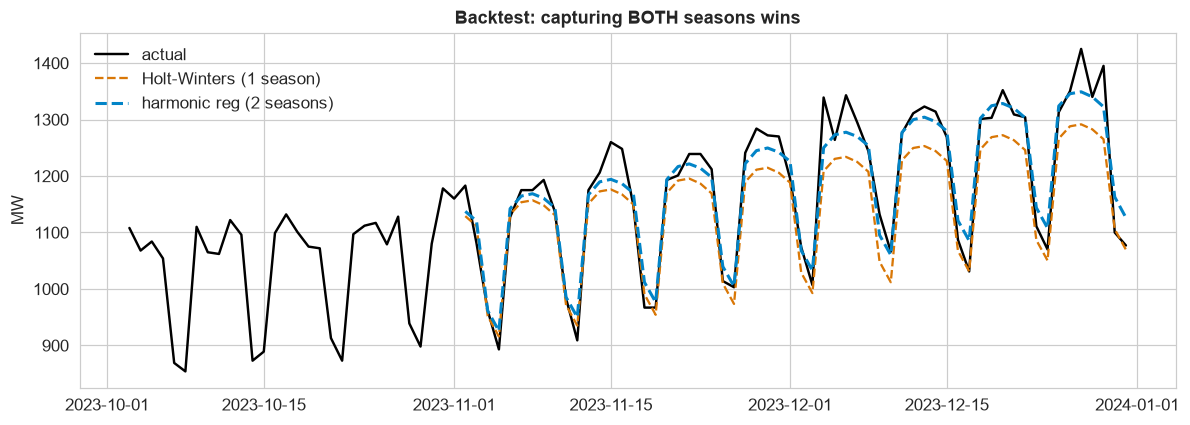

In [10]:
nmae = mae(test, snaive)
rows=[]
for name,f in [('weekly seasonal-naive',snaive),('Holt-Winters (1 season)',hw_fc),('harmonic reg (2 seasons)',hr_fc)]:
    rows.append({'model':name,'MAE':round(mae(test,f)),'RMSE':round(rmse(test,f)),'MAPE_%':round(mape(test,f),2),'MASE':round(mae(test,f)/nmae,2)})
print(pd.DataFrame(rows).to_string(index=False))
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(s.index[-90:], s.values[-90:], color='k', lw=1.6, label='actual')
ax.plot(test.index, hw_fc, '--', color=AMBER, label='Holt-Winters (1 season)'); ax.plot(test.index, hr_fc, '--', color=EM, lw=2, label='harmonic reg (2 seasons)')
ax.set(title='Backtest: capturing BOTH seasons wins', ylabel='MW'); ax.legend(); plt.tight_layout(); plt.show()

The verdict panel is unambiguous: the <strong>two-season harmonic regression wins</strong> (about 2.2% MAPE, MASE well below 1), beating the one-season Holt-Winters and cutting the baseline error by nearly 80%. The plot shows why: Holt-Winters gets the weekly zig-zag right but drifts off the yearly level, while the harmonic model tracks both.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 10 &#183; INTERPRET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Are the residuals clean?</div>
<div style="color:#4a5578;margin-top:6px">And what does the model say?</div>
</div>

In [11]:
resid = train.values - hr.predict(Xtr)
lb = acorr_ljungbox(resid, lags=[14])['lb_pvalue'].iloc[0]
print('harmonic-regression residual Ljung-Box p = %.2f -> %s' % (lb, 'little structure left' if lb>0.05 else 'some autocorrelation remains'))
dow_names=['Tue','Wed','Thu','Fri','Sat','Sun']
print('\nweekday effects vs Monday (MW):')
for name,coef in zip(dow_names, hr.params[2:8]): print('  %-4s %+6.0f' % (name, coef))

harmonic-regression residual Ljung-Box p = 0.03 -> some autocorrelation remains

weekday effects vs Monday (MW):
  Tue     +19
  Wed     +20
  Thu      +8
  Fri     -12
  Sat    -174
  Sun    -213


The residuals are small, though a Ljung-Box test flags a little leftover <strong>day-to-day autocorrelation</strong>, a short AR term (dynamic regression, in Take It Further) would mop it up. The fitted coefficients are readable: the <strong>weekend effect</strong> is a large negative shift (Saturday about 174 MW and Sunday about 213 MW below a Monday), and the Fourier terms trace the annual curve. A model you can both trust and explain is exactly what an operations team needs.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 11 &#183; DEPLOY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Refit on all data, forecast ahead</div>
<div style="color:#4a5578;margin-top:6px">With a prediction interval.</div>
</div>

next 30 days: average 1312 MW | day 1 = 1343 MW  (95% interval 1281 to 1404)


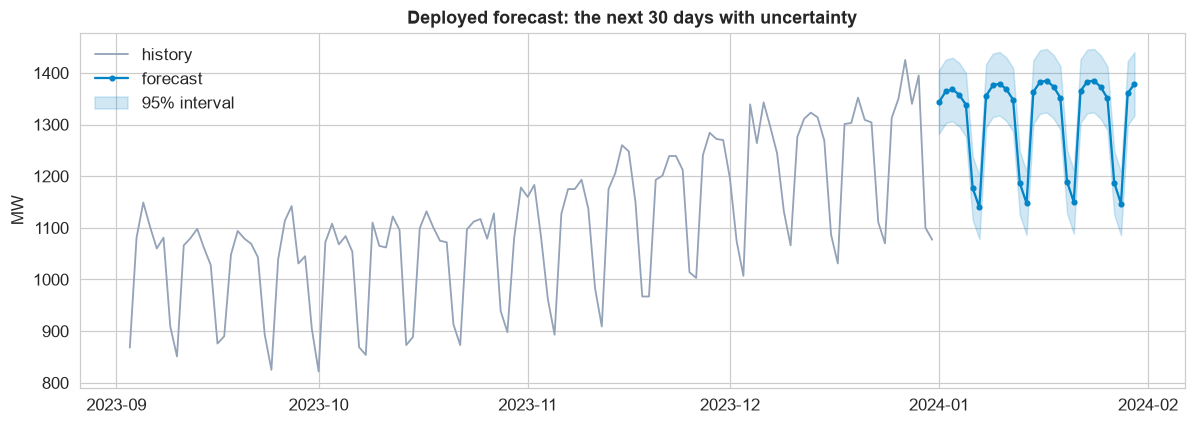

In [12]:
Xall = design(s.index, 0); final = sm.OLS(s.values, Xall).fit()
fut_idx = pd.date_range(s.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
pred = final.get_prediction(design(fut_idx, len(s))).summary_frame(alpha=0.05)
print('next 30 days: average %d MW | day 1 = %d MW  (95%% interval %d to %d)' % (pred['mean'].mean(), pred['mean'].iloc[0], pred['obs_ci_lower'].iloc[0], pred['obs_ci_upper'].iloc[0]))
fig,ax=plt.subplots(figsize=(11,4)); ax.plot(s.index[-120:], s.values[-120:], color=GREY, lw=1.2, label='history')
ax.plot(fut_idx, pred['mean'], 'o-', color=EM, ms=3, label='forecast')
ax.fill_between(fut_idx, pred['obs_ci_lower'], pred['obs_ci_upper'], color=EM, alpha=0.18, label='95% interval')
ax.set(title='Deployed forecast: the next 30 days with uncertainty', ylabel='MW'); ax.legend(); plt.tight_layout(); plt.show()

Before forecasting the real future we <strong>refit on all four years</strong>. The model projects the next month day by day, weekend dips and all, around an average near <strong>1,310 MW</strong>, with a 95% interval on each day. In production this reruns every morning as yesterday's actuals land, so the grid team always has a fresh, calendar-aware forecast with its uncertainty.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 12 &#183; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One paragraph for the control room</div>
<div style="color:#4a5578;margin-top:6px">Plain English, with the two rhythms.</div>
</div>

<strong>For the operations team:</strong> demand follows two clocks at once, a weekly one (weekdays run about 200 MW above weekends) and a yearly one (winter and summer peaks). Our forecast captures both and was accurate to about <strong>2.2%</strong> over the last two months, far better than repeating last week. Expect the next month to average around <strong>1,310 MW</strong>; schedule extra capacity for weekdays and the seasonal peak, and pull back on weekends. Plan against the daily <strong>range</strong>, and the forecast refreshes every morning.

## The forecasting method, in one view

1. **Define** the decision (daily demand for grid scheduling) and the baseline.
2. **Collect** the daily series.
3. **Inspect**: spot both the weekly and yearly rhythms.
4. **Decompose** with MSTL to separate the two seasonal cycles.
5. **Stationarity check**: trend-stationary, so model directly; the real challenge is multiple seasonality.
6. **Split in time** and set a weekly seasonal-naive baseline.
7. **One season**: Holt-Winters captures the week but misses the year.
8. **Both seasons**: harmonic regression with day-of-week dummies + yearly Fourier terms.
9. **Validate**: the two-season model wins clearly on the holdout.
10. **Interpret**: clean residuals and readable weekday/weekend effects.
11. **Deploy**: refit on all data, forecast ahead with an interval.
12. **Communicate** both rhythms and the range in plain English.

**The one idea to keep: when a series has more than one seasonal cycle, a one-season model (Holt-Winters, SARIMA) can only capture one, so reach for MSTL to see them and Fourier terms to model them all at once.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>